<a href="https://colab.research.google.com/github/Valeriaya512/R/blob/main/%E4%B8%BB%E6%88%90%E5%88%86%E5%88%86%E6%9E%90.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 主成分分析(Principal component analysis，PCA)

### 目的：把多個相關變數壓縮成少數幾個「主成分」，每個主成分代表一種潛在的模式與特性

#### 進行PCA的前置作業
*  進行變數標準化：去除變數平均值的影響，避免變異大的變數過度影響結果




| 特性    | 傳統 PCA   | 非負稀疏 PCA（NSPCA） |
| ----- | -------- | --------------- |
| 係數    | 有正有負     | 全部 ≥ 0          |
| 解釋難度  | 較難（正負抵消） | 較易（全是正向貢獻）      |
| 稀疏性   | 所有變數都有係數 | 只有少數變數有係數       |
| 解釋變異量 | 較高       | 較低（因有限制）        |
| 適用情境  | 純降維、預測   | 需要解釋意義          |

* 三個關鍵輸出
  1. 變異解釋量（sdev）：每個 PC 能解釋多少數據變異

  2. 係數矩陣（rotation）：每個原始變數在各 PC 的權重

  3. 主成分分數（x）：每個樣本在各 PC 的得分

* 如何決定取幾個 PC？
  1. 轉彎點法則（Elbow Method）：畫出累積解釋比例圖，找轉彎處

  2. 累積比例：通常取到累積解釋 70-90% 變異

* 實際應用
  1. 異常值偵測：找出在某个 PC 得分特別高/低的公司

  2. 分群：用 PC 分數做 clustering

  3. 特徵工程：用 PC 分數代替原始變數做建模

In [39]:
install.packages(c("tidyverse", "plotly", "reshape2", "nsprcomp"))


Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [ ]:
# 傳統 PCA 基本流程

# 假設有 5 個學生的 4 科成績
scores <- data.frame(
  數學 = c(80, 85, 90, 70, 95),
  物理 = c(75, 88, 92, 68, 90),
  化學 = c(82, 80, 88, 72, 85),
  英文 = c(90, 85, 78, 88, 82)
)

# 建立 PCA 模型
pca <- prcomp(scores, scale. = TRUE)

# 檢視結果
summary(pca)
# 看前兩個 PC 能解釋多少變異
# PC1 可能代表「理科能力」，PC2 可能代表「文科能力」

# 每個學生的 PC 分數
pca$x

# 解讀：
# 如果 PC1 在數學、物理、化學的係數都很高 → PC1 代表「理科能力」
# 如果 PC2 在英文的係數很高 → PC2 代表「文科能力」

Importance of components:
                          PC1    PC2     PC3     PC4
Standard deviation     1.8663 0.5716 0.38242 0.20908
Proportion of Variance 0.8708 0.0817 0.03656 0.01093
Cumulative Proportion  0.8708 0.9525 0.98907 1.00000

PC1,PC2,PC3,PC4
-1.0737683,-0.86764287,0.27366914,0.04822030
0.1666417,0.04927162,-0.48491029,0.26254713
1.9736726,0.42279832,0.44631468,0.08686326
-2.5689707,0.58177649,0.03758791,-0.10659654
1.5024248,-0.18620357,-0.27266144,-0.29103414


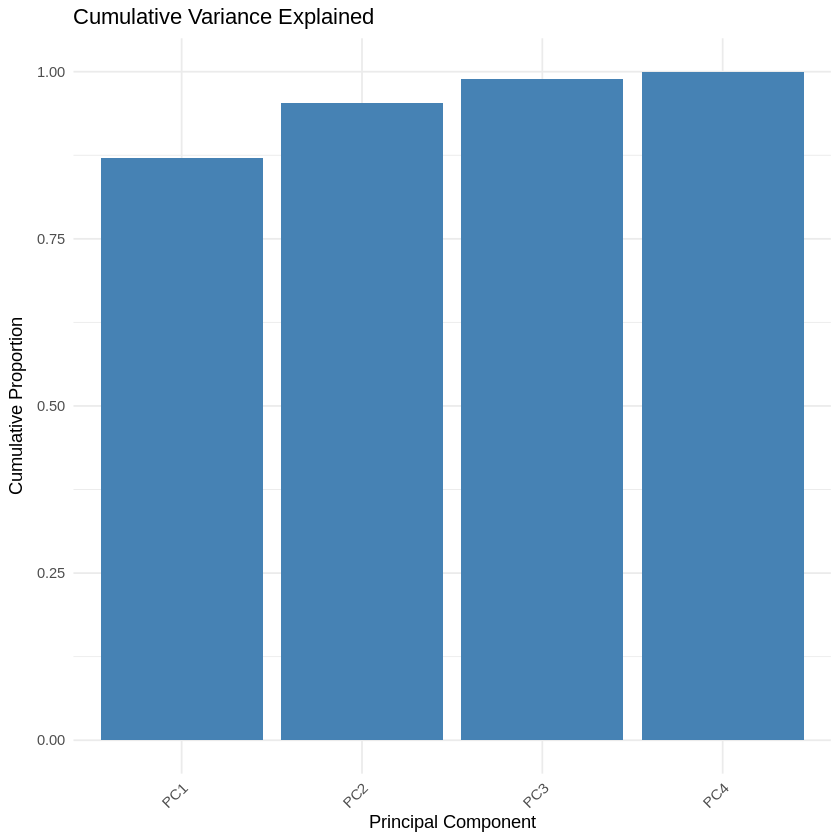

In [ ]:
# 決定取幾個 PC

library(tidyverse)
library(plotly)
library(ggplot2)

scores <- data.frame(
  數學 = c(80, 85, 90, 70, 95),
  物理 = c(75, 88, 92, 68, 90),
  化學 = c(82, 80, 88, 72, 85),
  英文 = c(90, 85, 78, 88, 82)
)

pca <- prcomp(scores, scale. = TRUE)

# 計算解釋變異
var.exp <- tibble(
  pc = paste0("PC", 1:4),
  prop = pca$sdev^2 / sum(pca$sdev^2),
  cum_prop = cumsum(pca$sdev^2) / sum(pca$sdev^2)
)

# 畫圖
ggplot(var.exp, aes(x = pc, y = cum_prop)) +
  geom_col(fill = "steelblue") +
  labs(
    title = "Cumulative Variance Explained",
    x = "Principal Component",
    y = "Cumulative Proportion"
  ) +
  theme_minimal() +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1)
  )

# 解讀：
# 如果 PC2 的累積比例已達 85% → 取前 2 個 PC 就夠了
# 如果到 PC4 才到 90% → 可能需要更多 PC

In [40]:
# 非負稀疏 PCA（易於解釋）

library(nsprcomp)

financial_data <- data.frame(
  roe = rnorm(100, 10, 3),           # 股東權益報酬率
  eps = rnorm(100, 5, 2),            # 每股盈餘
  roa = rnorm(100, 8, 3),            # 資產報酬率
  gross_margin = rnorm(100, 30, 8),  # 毛利率
  operating_margin = rnorm(100, 15, 4),  # 營業利潤率
  net_margin = rnorm(100, 12, 3),    # 淨利率
  book_value = rnorm(100, 50, 15),   # 帳面價值
  cash_flow = rnorm(100, 15, 5),     # 現金流
  revenue_growth = rnorm(100, 10, 6), # 營收成長率
  profit_growth = rnorm(100, 12, 8)   # 獲利成長率
)

# 假設 10 個財務指標
nspca <- nscumcomp(
  financial_data,
  k = 50,        # 限制非零係數個數
  nneg = TRUE,   # 係數全部非負
  scale. = TRUE
)

# 看係數矩陣（只顯示前 3 個 PC）
nspca$rotation[, 1:3]

# 結論：
# PC1 主要由operating_margin主導
# PC2 主要由 roa 主導
# PC3 主要由 eps 主導

,PC1,PC2,PC3
roe,0.2056309,0.0000000,0.0000000
eps,0.0000000,0.3605661,0.7295100
roa,0.0000000,0.7164624,0.0000000
gross_margin,0.4070290,0.2294664,0.3001788
operating_margin,0.7680268,0.0000000,0.1217411
net_margin,0.0000000,0.0000000,0.0000000
book_value,0.0000000,0.0000000,0.5682752
cash_flow,0.0000000,0.1932011,0.0000000
revenue_growth,0.4496423,0.5164224,0.0000000
profit_growth,0.0000000,0.0000000,0.1998755


[1] "=== 數據前 5 列 ==="
        roe      eps       roa gross_margin operating_margin net_margin
1  8.318573 3.579187 14.596431     24.27806         14.70578  10.194321
2  9.309468 5.513767 11.937239     23.97849         10.32539   9.018904
3 14.676125 4.506616  7.204565     22.49169         12.46101  15.080355
4 10.211525 4.304915  9.629582     21.57989         14.88463  14.253184
5 10.387863 3.096763  6.756980     26.50272         17.68278   7.472500
  book_value cash_flow revenue_growth profit_growth
1   66.11018 11.358904      12.137700      3.887087
2   49.58980  7.297788       6.051939      5.669489
3   49.50004 11.534527      15.131213     14.396749
4   27.25899 15.594247      16.917617     25.112415
5   61.85578  8.176453      11.657647     20.676936
[1] "=== 傳統 PCA 解釋變異 ==="
Importance of components:
                          PC1    PC2    PC3    PC4    PC5     PC6     PC7
Standard deviation     1.2152 1.1359 1.1131 1.0689 1.0235 0.96101 0.94237
Proportion of Variance 0.1477 0.12

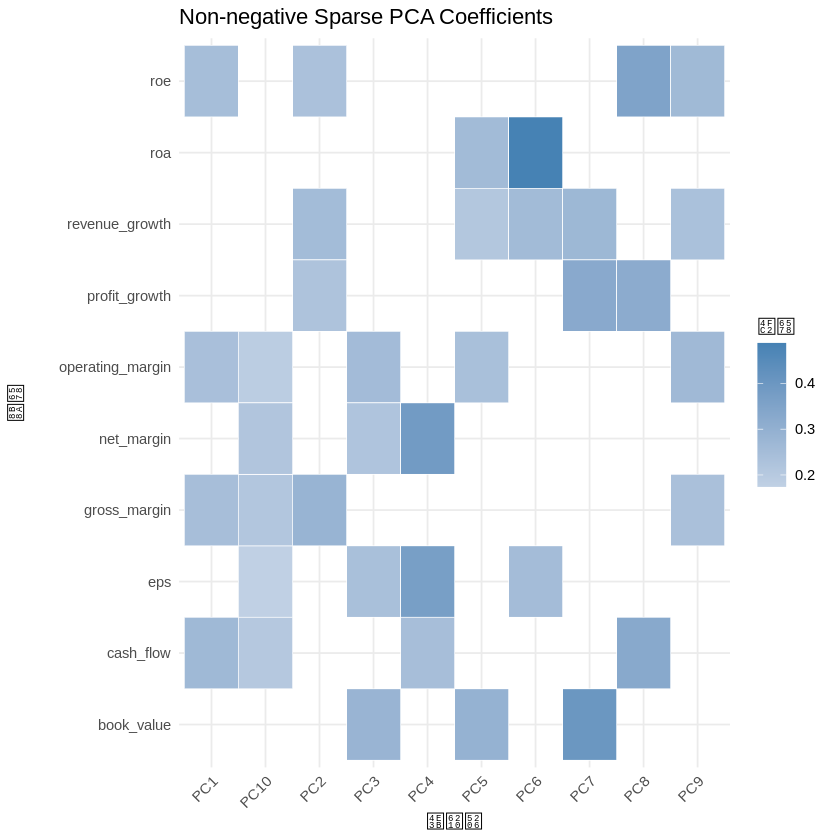

In [38]:
# 非負稀疏主成分分析（NSPCA）

library(tidyverse)
library(plotly)
library(reshape2)

set.seed(123)

# ============================================
# 1. 建立財務數據（10 個指標）
# ============================================
financial_data <- data.frame(
  roe = rnorm(100, 10, 3),           # 股東權益報酬率
  eps = rnorm(100, 5, 2),            # 每股盈餘
  roa = rnorm(100, 8, 3),            # 資產報酬率
  gross_margin = rnorm(100, 30, 8),  # 毛利率
  operating_margin = rnorm(100, 15, 4),  # 營業利潤率
  net_margin = rnorm(100, 12, 3),    # 淨利率
  book_value = rnorm(100, 50, 15),   # 帳面價值
  cash_flow = rnorm(100, 15, 5),     # 現金流
  revenue_growth = rnorm(100, 10, 6), # 營收成長率
  profit_growth = rnorm(100, 12, 8)   # 獲利成長率
)

print("=== 數據前 5 列 ===")
print(head(financial_data, 5))

# ============================================
# 2. 傳統 PCA
# ============================================
pca <- prcomp(financial_data, scale. = TRUE)

print("=== 傳統 PCA 解釋變異 ===")
print(summary(pca))

# ============================================
# 3. 手動實現非負稀疏 PCA
# ============================================

# 步驟 1: 取絕對值（確保非負）
rotation_nn <- abs(pca$rotation)

# 步驟 2: 稀疏化（將小於閾值的設為 0）
threshold <- 0.35  # 閾值越高越稀疏
rotation_sparse <- rotation_nn
rotation_sparse[rotation_sparse < threshold] <- 0

# 步驟 3: 重新歸一化（讓每行加總為 1）
rotation_sparse <- apply(rotation_sparse, 2, function(x) {
  if (sum(x) > 0) {
    x / sum(x)
  } else {
    x
  }
})

print("=== 非負稀疏係數矩陣 ===")
print(round(rotation_sparse, 3))

# ============================================
# 4. 計算主成分分數
# ============================================
scores <- as.data.frame(
  scale(financial_data) %*% rotation_sparse
)
colnames(scores) <- paste0("PC", 1:ncol(rotation_sparse))
scores$sample_id <- 1:nrow(financial_data)

print("=== 前 5 個樣本的主成分分數 ===")
print(head(scores, 5))

# ============================================
# 5. 計算解釋變異
# ============================================
var_original <- apply(scale(financial_data) %*% rotation_sparse, 2, var)
total_var <- sum(var_original)

var.exp <- tibble(
  pc = paste0("PC", 1:ncol(rotation_sparse)),
  變異數 = round(var_original, 3),
  解釋比例 = round(var_original / total_var, 3),
  累積比例 = round(cumsum(var_original) / total_var, 3)
)

print("=== 解釋變異 ===")
print(var.exp)

# ============================================
# 6. 視覺化 1: 係數熱力圖
# ============================================
coef_df <- as.data.frame(rotation_sparse)
coef_df$變數 <- rownames(coef_df)
coef_df_long <- coef_df %>%
  pivot_longer(cols = -變數, names_to = "主成分", values_to = "係數")

p1 <- ggplot(coef_df_long %>% filter(係數 > 0),
       aes(x = 主成分, y = 變數, fill = 係數)) +
  geom_tile(color = "white") +
  scale_fill_gradient2(low = "white", high = "steelblue") +
  labs(title = "Non-negative Sparse PCA Coefficients") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

p1 # Display the plot

### 線性降維 vs 非線性降維
降維（Dimensionality Reduction） 是將高維數據壓縮到低維空間，同時保留關鍵資訊的技術。

*   線性降維
*   非線性降維



| 特性   | 線性降維           | 非線性降維                 |
| ---- | -------------- | --------------------- |
| 轉換方式 | 原始特徵的線性組合（加權和） | 複雜的非線性映射              |
| 假設   | 數據呈線性關係        | 數據呈複雜、彎曲的流形結構         |
| 保留結構 | 全局結構（整體分佈）     | 局部結構（鄰近點關係）           |
| 可解釋性 | 高（主成分可追溯回原始特徵） | 低（潛在特徵抽象）             |
| 計算效率 | 高（適合大數據）       | 低（計算複雜）               |
| 典型算法 | PCA、LDA、MDS    | t-SNE、UMAP、LLE、Isomap |
| 適用場景 | 特徵壓縮、去噪、預處理    | 高維可視化、複雜模式發現          |

| 方法    | A/B 群分開程度 | 速度     | 可解釋性 | 適用情境         |
| ----- | --------- | ------ | ---- | ------------ |
| PCA   | ❌ 混在一起    | ⚡⚡⚡ 最快 | ✅ 高  | 變數相關、需要解釋    |
| t-SNE | ✅ 清楚分開    | 🐌 慢   | ❌ 低  | 視覺化、分群       |
| UMAP  | ✅ 清楚分開    | ⚡⚡ 中等  | ❌ 低  | 大數據、視覺化 + 分群 |

In [44]:
# 定義需要的套件清單
required_packages <- c("factoextra", "FactoMineR", "Rtsne", "umap", "tidyverse", "ggrepel")

# 檢查並安裝缺失的套件
new_packages <- required_packages[!(required_packages %in% installed.packages()[, "Package"])]
if (length(new_packages)) install.packages(new_packages)

# 載入所有套件
library(factoextra)   # PCA 可視化
library(FactoMineR)   # 執行 PCA 分析
library(Rtsne)        # t-SNE 非線性降維
library(umap)         # UMAP 非線性降維
library(tidyverse)    # 數據處理和 ggplot2 繪圖
library(ggrepel)      # 美觀的標籤註解

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘colorspace’, ‘fracdiff’, ‘lmtest’, ‘timeDate’, ‘urca’, ‘zoo’, ‘RcppArmadillo’, ‘Deriv’, ‘forecast’, ‘rbibutils’, ‘litedown’, ‘corrplot’, ‘doBy’, ‘SparseM’, ‘MatrixModels’, ‘Rdpack’, ‘minqa’, ‘nloptr’, ‘reformulas’, ‘markdown’, ‘jpeg’, ‘viridis’, ‘ggsci’, ‘cowplot’, ‘ggsignif’, ‘gridExtra’, ‘polynom’, ‘rstatix’, ‘carData’, ‘abind’, ‘Formula’, ‘pbkrtest’, ‘quantreg’, ‘lme4’, ‘estimability’, ‘mvtnorm’, ‘numDeriv’, ‘gridtext’, ‘showtextdb’, ‘RcppTOML’, ‘here’, ‘png’, ‘RcppEigen’, ‘dendextend’, ‘ggpubr’, ‘car’, ‘DT’, ‘ellipse’, ‘emmeans’, ‘flashClust’, ‘ggtext’, ‘irlba’, ‘leaps’, ‘multcompView’, ‘scatterplot3d’, ‘showtext’, ‘sysfonts’, ‘reticulate’, ‘RSpectra’


Welcome to factoextra!

Want to learn more? See two factoextra-related books at https://www.datanovia.com/library/principal-component-methods



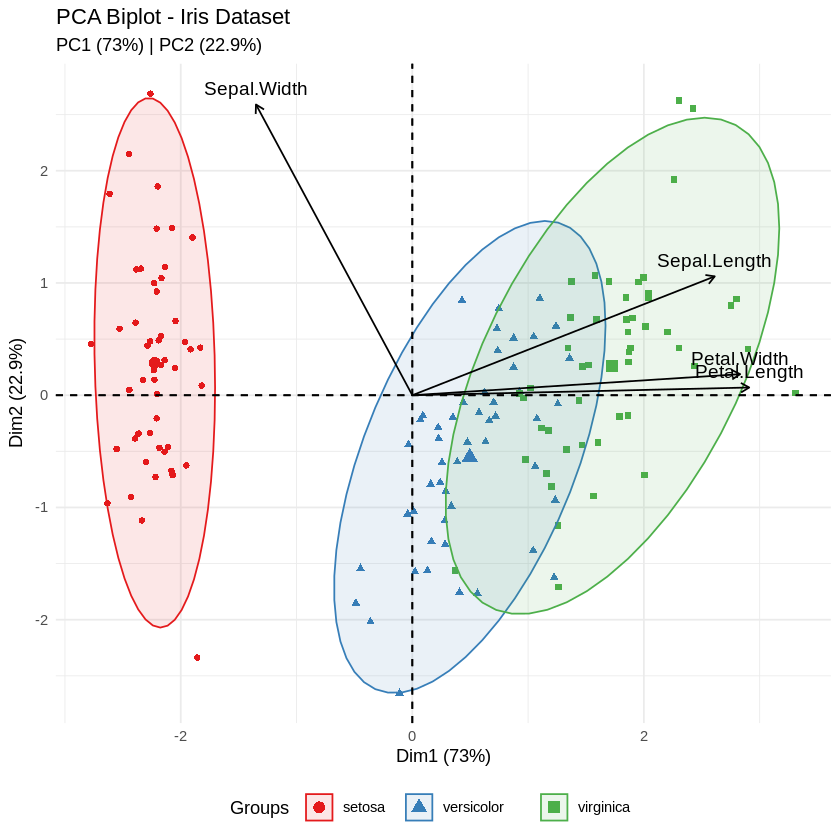

In [ ]:
# 線性降維 - PCA（主成分分析）
library(factoextra)
library(FactoMineR)
library(tidyverse)

# 載入鳶尾花數據集
data(iris)

# 只選取數值型變數
iris_numeric <- iris %>% select(where(is.numeric))

# 執行 PCA 分析
pca_result <- PCA(iris_numeric, graph = FALSE)

# 提取特徵值與方差百分比
eig_val <- get_eigenvalue(pca_result)

# 獲取 PC1 和 PC2 的方差比例
pc1_var <- round(eig_val[1, "variance.percent"], 1)
pc2_var <- round(eig_val[2, "variance.percent"], 1)

# 繪製 PCA 雙標圖
# 修正：移除 gradient.cols 並調整 col.var 設定，以避免離散與連續尺度衝突
fviz_pca_biplot(pca_result,
        geom.ind = "point",
        habillage = iris$Species,      # 樣本按物種分組 (離散)
        palette = "Set1",           # 為離散分組指定配色
        addEllipses = TRUE,          # 添加置信橢圓
        label = "var",
        col.var = "black",          # 將變數箭頭設為單一顏色避免尺度衝突
        title = "PCA Biplot - Iris Dataset",
        subtitle = paste0("PC1 (", pc1_var, "%) | PC2 (", pc2_var, "%)")) +
  theme_minimal() +
  theme(legend.position = "bottom")

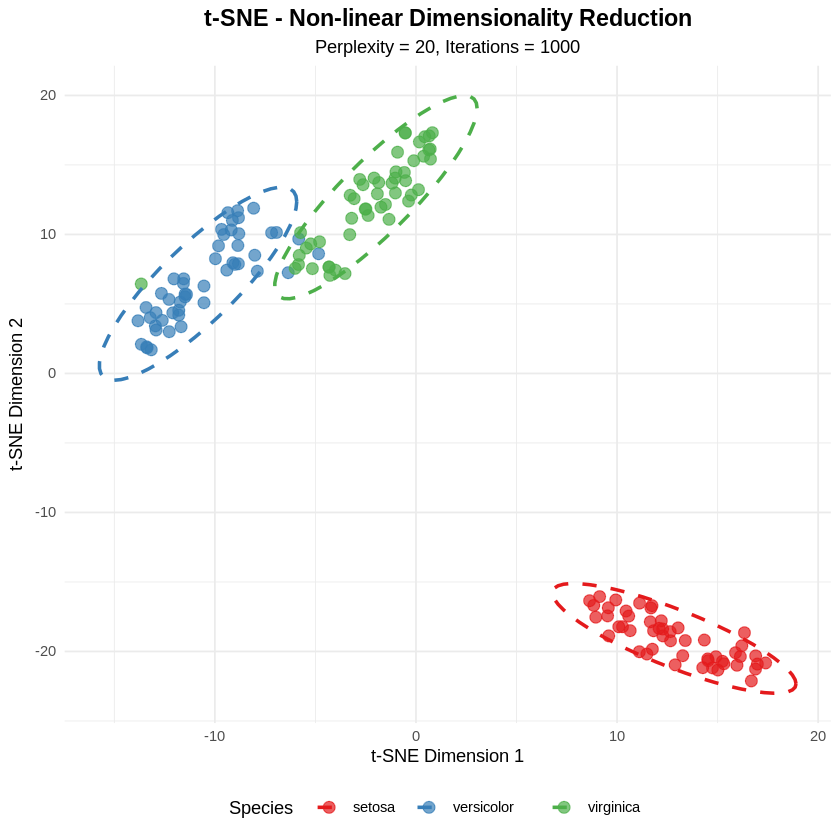

In [ ]:
# 非線性降維 - t-SNE
library(Rtsne)        # t-SNE 非線性降維
library(tidyverse)    # 數據處理和 ggplot2 繪圖
library(ggrepel)

# 確保數值型數據存在
if (!exists("iris_numeric")) {
  data(iris)
  iris_numeric <- iris %>% select(where(is.numeric))
}

# 設定隨機種子，確保結果可重複
set.seed(42)

# 使用 Rtsne 套件執行 t-SNE 降維
# 注意：Rtsne 需要輸入矩陣 (matrix) 格式
tsne_result <- Rtsne(as.matrix(iris_numeric),
        dims = 2,           # 降維到 2 維
        perplexity = 20,    # 鄰近點數量
        theta = 0.5,        # 加速參數
        pca = FALSE,
        max_iter = 1000,
        check_duplicates = FALSE,
        verbose = FALSE)

# 提取 t-SNE 座標
tsne_coords <- as.data.frame(tsne_result$Y) %>%
  mutate(Species = iris$Species)

# 繪製 t-SNE 散點圖
ggplot(tsne_coords, aes(x = V1, y = V2, color = Species)) +
  geom_point(size = 3, alpha = 0.7) +
  stat_ellipse(level = 0.95, linetype = "dashed", size = 1) +
  labs(
    title = "t-SNE - Non-linear Dimensionality Reduction",
    subtitle = "Perplexity = 20, Iterations = 1000",
    x = "t-SNE Dimension 1",
    y = "t-SNE Dimension 2",
    color = "Species"
  ) +
  scale_color_brewer(palette = "Set1") +
  theme_minimal() +
  theme(
    legend.position = "bottom",
    plot.title = element_text(hjust = 0.5, face = "bold", size = 14),
    plot.subtitle = element_text(hjust = 0.5, size = 11)
  )

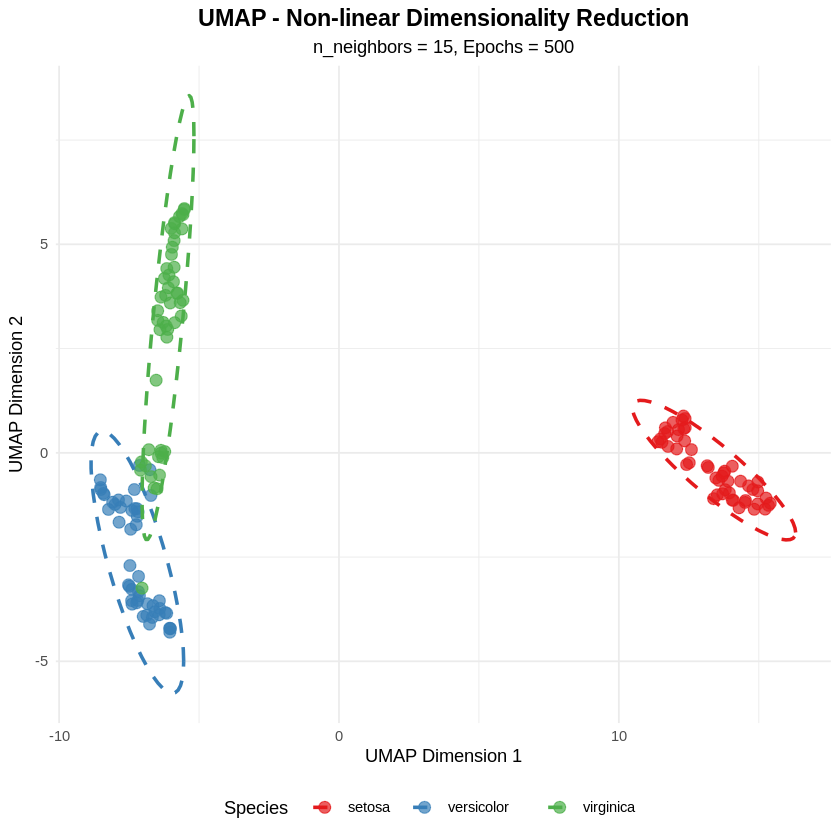

In [ ]:
# 非線性降維 - UMAP
library(umap)         # UMAP 非線性降維
library(tidyverse)    # 數據處理和 ggplot2 繪圖
library(ggrepel)

# 確保數值型數據存在
if (!exists("iris_numeric")) {
  data(iris)
  iris_numeric <- iris %>% select(where(is.numeric))
}

# 設定隨機種子
set.seed(42)

# 使用 umap 套件執行 UMAP 降維
umap_result <- umap(iris_numeric,
        # 降維參數
        n_neighbors = 15,   # 鄰近點數量
        n_components = 2,   # 降維到 2 維
        metric = "euclidean", # 距離度量
        epoch = 500,        # 迭代次數
        verbose = FALSE)    # 不顯示進度

# 提取 UMAP 座標
umap_coords <- as.data.frame(umap_result$layout) %>%
  mutate(Species = iris$Species)

# 繪製 UMAP 散點圖
ggplot(umap_coords, aes(x = V1, y = V2, color = Species)) +
  geom_point(size = 3, alpha = 0.7) +
  stat_ellipse(level = 0.95, linetype = "dashed", size = 1) +
  labs(
    title = "UMAP - Non-linear Dimensionality Reduction",
    subtitle = "n_neighbors = 15, Epochs = 500",
    x = "UMAP Dimension 1",
    y = "UMAP Dimension 2",
    color = "Species"
  ) +
  scale_color_brewer(palette = "Set1") +
  theme_minimal() +
  theme(
    legend.position = "bottom",
    plot.title = element_text(hjust = 0.5, face = "bold", size = 14),
    plot.subtitle = element_text(hjust = 0.5, size = 11)
  )